# Week 6 - Introduction to Machine Learning
## Exercise 19: Find another dataset on any of data hosting websites (such as UCI or Kaggle) download it and repeat all the steps on it.

In [2]:
import pandas as pd 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 
import matplotlib.pyplot as plt
import numpy as np

### Exercise 5: To open the dataset, we will be using Pandas library. Thus, initially we need to import the necessary libraries:

In [3]:
file_name = 'forestfires.csv'

df = pd.read_csv(file_name, sep=',') 

display(df.head())

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [81]:
print(df.head())

   X  Y month  day  FFMC   DMC     DC  ISI  temp  RH  wind  rain  area
0  7  5   mar  fri  86.2  26.2   94.3  5.1   8.2  51   6.7   0.0   0.0
1  7  4   oct  tue  90.6  35.4  669.1  6.7  18.0  33   0.9   0.0   0.0
2  7  4   oct  sat  90.6  43.7  686.9  6.7  14.6  33   1.3   0.0   0.0
3  8  6   mar  fri  91.7  33.3   77.5  9.0   8.3  97   4.0   0.2   0.0
4  8  6   mar  sun  89.3  51.3  102.2  9.6  11.4  99   1.8   0.0   0.0


### Exercise 6: Now we can start analysing the data to get good understating of it.

In [14]:
# Display basic information about the dataset 
print("Shape of the DataFrame:") 
print(df.shape) 

print("\nColumns in the DataFrame:") 
print(df.columns)

Shape of the DataFrame:
(517, 13)

Columns in the DataFrame:
Index(['X', 'Y', 'month', 'day', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH',
       'wind', 'rain', 'area'],
      dtype='object')


### Exercise 7: To get a statistical analysis of the data we can use pandas describe tool, as follows:

In [15]:
# Display summary statistics of numerical columns 
print("\nSummary Statistics:") 
display(df.describe())


Summary Statistics:


,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


### Exercise 8: To check for any missing data, we can use:

In [4]:
# Check for any missing values 
print("\nMissing Values:") 
print(df.isnull().sum())


Missing Values:
X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64


### Exercise 9: To check for duplicated row, we can use:

In [39]:
# Check for any duplicate rows 
print(f"Number of Duplicate Rows: {df.duplicated().sum()}")
df[df.duplicated()]

Number of Duplicate Rows: 4


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
53,4,3,aug,wed,92.1,111.2,654.1,9.6,20.4,42,4.9,0.0,0.00
100,3,4,aug,sun,91.4,142.4,601.4,10.6,19.8,39,5.4,0.0,0.00
215,4,4,mar,sat,91.7,35.8,80.8,7.8,17.0,27,4.9,0.0,28.66
303,3,6,jun,fri,91.1,94.1,232.1,7.1,19.2,38,4.5,0.0,0.00


### Exercise 10: To check for column data types, we can use:

In [40]:
print("\nData types of the columns:") 
print(df.dtypes)


Data types of the columns:
X          int64
Y          int64
month     object
day       object
FFMC     float64
DMC      float64
DC       float64
ISI      float64
temp     float64
RH         int64
wind     float64
rain     float64
area     float64
dtype: object


### Exercise 11: We can asse the importance of the feature using the correlation matrix as follows:

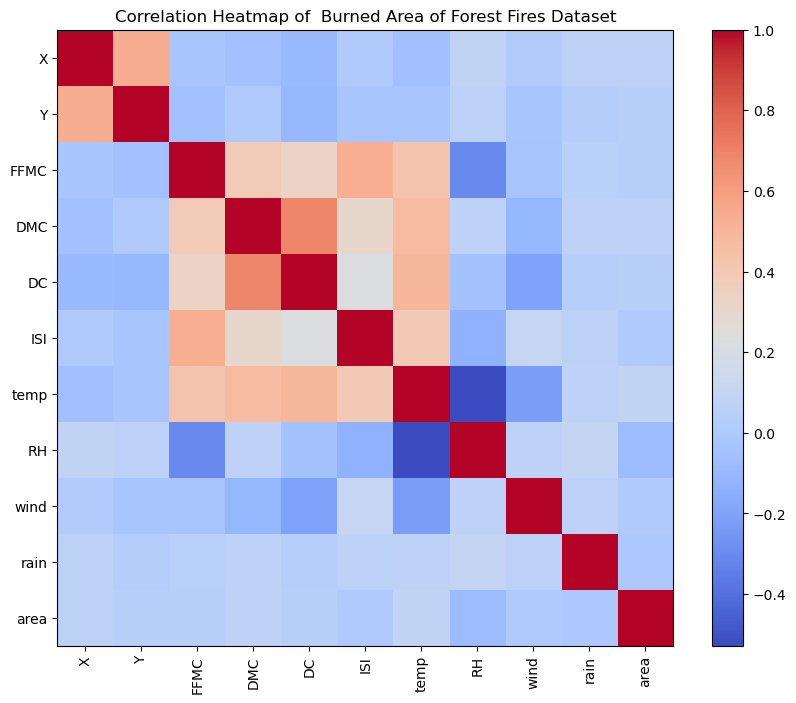

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
X,1.000000,0.539548,-0.021039,-0.048384,-0.085916,0.006210,-0.051258,0.085223,0.018798,0.065387,0.063385
Y,0.539548,1.000000,-0.046308,0.007782,-0.101178,-0.024488,-0.024103,0.062221,-0.020341,0.033234,0.044873
FFMC,-0.021039,-0.046308,1.000000,0.382619,0.330512,0.531805,0.431532,-0.300995,-0.028485,0.056702,0.040122
DMC,-0.048384,0.007782,0.382619,1.000000,0.682192,0.305128,0.469594,0.073795,-0.105342,0.074790,0.072994
DC,-0.085916,-0.101178,0.330512,0.682192,1.000000,0.229154,0.496208,-0.039192,-0.203466,0.035861,0.049383
ISI,0.006210,-0.024488,0.531805,0.305128,0.229154,1.000000,0.394287,-0.132517,0.106826,0.067668,0.008258
temp,-0.051258,-0.024103,0.431532,0.469594,0.496208,0.394287,1.000000,-0.527390,-0.227116,0.069491,0.097844
RH,0.085223,0.062221,-0.300995,0.073795,-0.039192,-0.132517,-0.527390,1.000000,0.069410,0.099751,-0.075519
wind,0.018798,-0.020341,-0.028485,-0.105342,-0.203466,0.106826,-0.227116,0.069410,1.000000,0.061119,0.012317
rain,0.065387,0.033234,0.056702,0.074790,0.035861,0.067668,0.069491,0.099751,0.061119,1.000000,-0.007366


In [42]:
# Selecting only numerical columns 
numerical_columns = df.select_dtypes(include=['int64', 'float64']) 

# Calculating correlations 
correlations = numerical_columns.corr() 

# Creating a basic heatmap to visualize the correlations 
plt.figure(figsize=(10, 8)) 
plt.imshow(correlations, cmap='coolwarm', interpolation='nearest') 
plt.colorbar() 
plt.xticks(range(len(correlations)), correlations.columns, rotation=90) 
plt.yticks(range(len(correlations)), correlations.columns) 
plt.title('Correlation Heatmap of  Burned Area of Forest Fires Dataset') 
plt.show()

correlations

### Exercise 12: To understand the different distributions

In [43]:
# Generate value counts for categorical variables 
print("\nValue Counts for Categorical Variables:") 
print(df['month'].value_counts())
print()
print(df['day'].value_counts())


Value Counts for Categorical Variables:
month
aug    184
sep    172
mar     54
jul     32
feb     20
jun     17
oct     15
apr      9
dec      9
jan      2
may      2
nov      1
Name: count, dtype: int64

day
sun    95
fri    85
sat    84
mon    74
tue    64
thu    61
wed    54
Name: count, dtype: int64


### Exercise 13: We can easily visualise the data using matplotlib

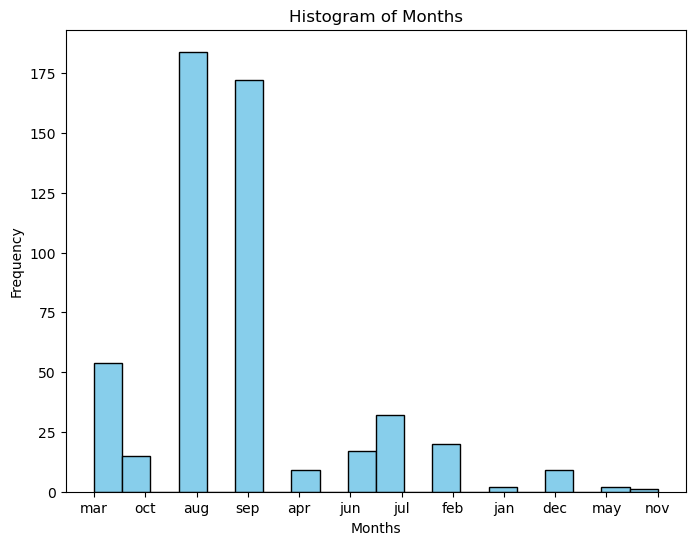

In [6]:
# Example: Histogram of Months
plt.figure(figsize=(8, 6)) 
plt.hist(df['month'], bins=20, color='skyblue', edgecolor='black') 
plt.title('Histogram of Months') 
plt.xlabel('Months') 
plt.ylabel('Frequency') 
plt.show()

### Exercise 14:

In [67]:
# Selecting the feature and target variables 
X = df[['FFMC']] # Feature variable 
y = df['area'] # Target variable

# Splitting the data into training and testing sets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Creating and fitting the model 
model = LinearRegression() 
model.fit(X_train, y_train)

# Predicting the target values 
y_pred = model.predict(X_test)

### Exercise 15: Measure the model performance using Mean Absolute Error, Mean Squared Error, and Calculating R-squared.

In [68]:
# Calculating Mean Absolute Error 
mae = mean_absolute_error(y_test, y_pred) 
print("Mean Absolute Error:", mae) 

# Calculating Mean Squared Error 
mse = mean_squared_error(y_test, y_pred) 
print("Mean Squared Error:", mse) 

# Calculating R-squared 
r2 = r2_score(y_test, y_pred) 
print("R-squared:", r2)

Mean Absolute Error: 26.128102736635633
Mean Squared Error: 12228.183921899277
R-squared: -0.011660203191379281


### Exercise 16: Visualise the model performance

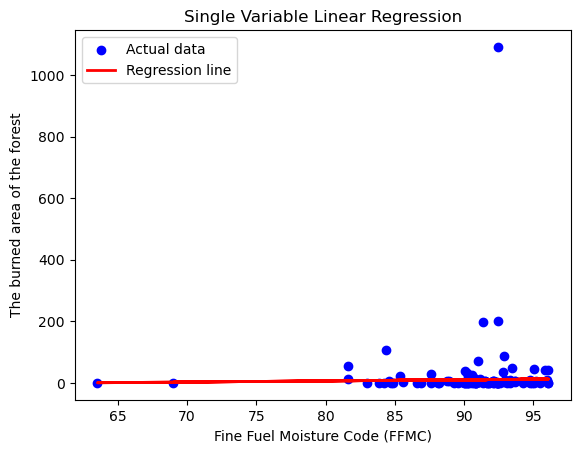

In [70]:
# Plotting the data points and the regression line 
plt.scatter(X_test, y_test, color='blue', label='Actual data') 
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression line') 
plt.title('Single Variable Linear Regression') 
plt.xlabel('Fine Fuel Moisture Code (FFMC)') 
plt.ylabel('The burned area of the forest') 
plt.legend() 
plt.show()

### Exercise 17: Try 3 different independent variables and compare the results. Write a comment on the best variable for the prediction (make sure that the variable you are testing is a numeric one as we cannot use a string as a number).

Performance for temp:
Mean Absolute Error (MAE): 26.01768004967478
Mean Squared Error (MSE): 12137.623184362401
R-squared (R²): -0.0041679463916068915 



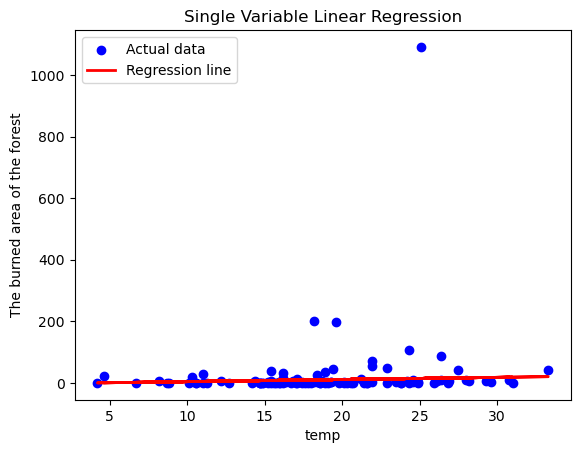


Performance for RH:
Mean Absolute Error (MAE): 25.99770439552182
Mean Squared Error (MSE): 12179.874167819698
R-squared (R²): -0.00766344815887221 



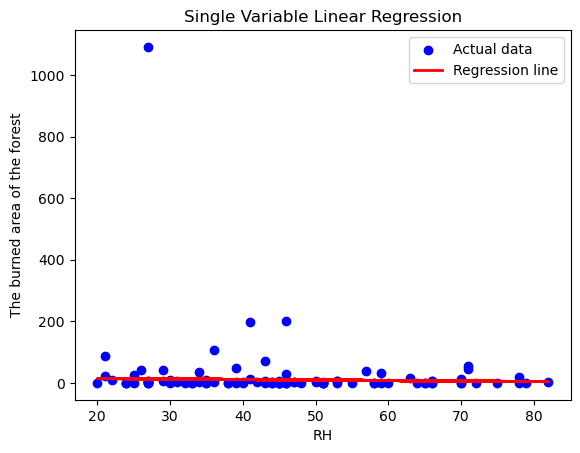


Performance for rain:
Mean Absolute Error (MAE): 26.095952251355847
Mean Squared Error (MSE): 12241.539325136268
R-squared (R²): -0.01276512032696786 



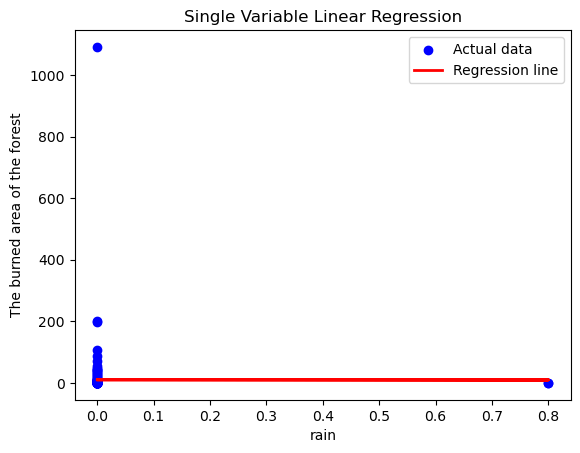

In [73]:
# List of independent variables to test
independent_variables = ['temp', 'RH', 'rain']

# Dictionary to store the results
results = {}

for var in independent_variables:
    # Selecting the feature and target variables
    X = df[[var]]  # Feature variable
    y = df['area']  # Target variable

    # Splitting the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

    # Creating and fitting the model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predicting the target values
    y_pred = model.predict(X_test)

    # Evaluating the model
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Storing the results
    results[var] = {'MAE': mae, 'MSE': mse, 'R2': r2}

    # Print the performance metrics for each variable
    print(f"Performance for {var}:")
    print(f"Mean Absolute Error (MAE): {mae}")
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"R-squared (R²): {r2} \n")

    # Plotting the data points and the regression line 
    plt.scatter(X_test, y_test, color='blue', label='Actual data') 
    plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression line') 
    plt.title('Single Variable Linear Regression') 
    plt.xlabel(var) 
    plt.ylabel('The burned area of the forest') 
    plt.legend() 
    plt.show()

    print()


#### Finding the best variable based on Mean Absolute Error (MAE)

The best variable for prediction based on MAE is RH with a MAE value of 25.99770439552182. 



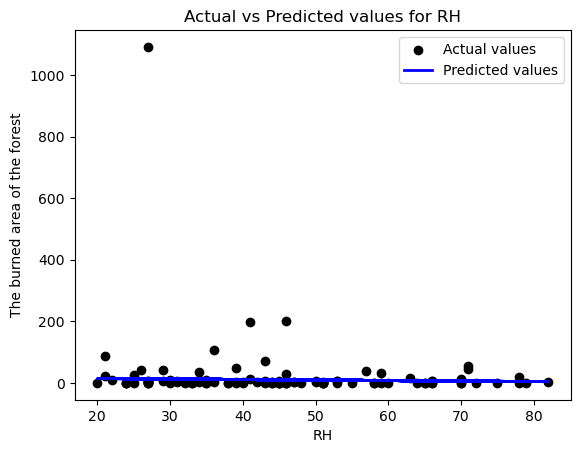

In [75]:
# Finding the best variable based on Mean Absolute Error (MAE)
best_var_mae = min(results, key=lambda x: results[x]['MAE'])
print(f"The best variable for prediction based on MAE is {best_var_mae} with a MAE value of {results[best_var_mae]['MAE']}. \n")

# Plotting the actual vs predicted values for the best variable based on MAE
X = df[[best_var_mae]]
y = df['area']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

plt.scatter(X_test, y_test, color='black', label='Actual values')
plt.plot(X_test, y_pred, color='blue', linewidth=2, label='Predicted values')
plt.title(f'Actual vs Predicted values for {best_var_mae}')
plt.xlabel(best_var_mae)
plt.ylabel('The burned area of the forest')
plt.legend()
plt.show()


#### Finding the best variable based on Mean Squared Error (MSE)

The best variable for prediction based on MSE is temp with a MSE value of 12137.623184362401. 



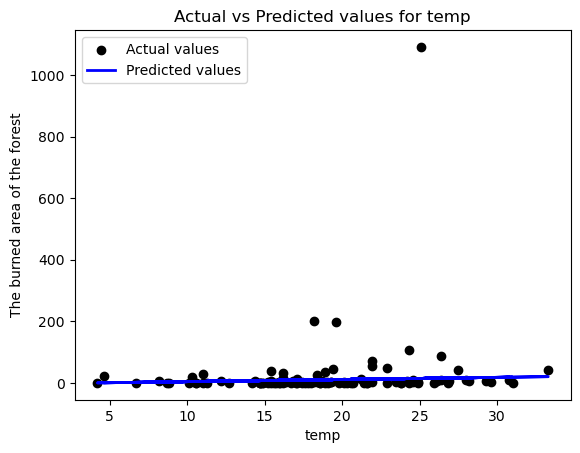

In [76]:
# Finding the best variable based on Mean Squared Error (MSE)
best_var_mse = min(results, key=lambda x: results[x]['MSE'])
print(f"The best variable for prediction based on MSE is {best_var_mse} with a MSE value of {results[best_var_mse]['MSE']}. \n")

# Plotting the actual vs predicted values for the best variable based on MSE
X = df[[best_var_mse]]
y = df['area']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

plt.scatter(X_test, y_test, color='black', label='Actual values')
plt.plot(X_test, y_pred, color='blue', linewidth=2, label='Predicted values')
plt.title(f'Actual vs Predicted values for {best_var_mse}')
plt.xlabel(best_var_mse)
plt.ylabel('The burned area of the forest')
plt.legend()
plt.show()

#### Finding the best variable based on R-squared value

The best variable for prediction based on R-squared is temp with an R-squared value of -0.0041679463916068915. 



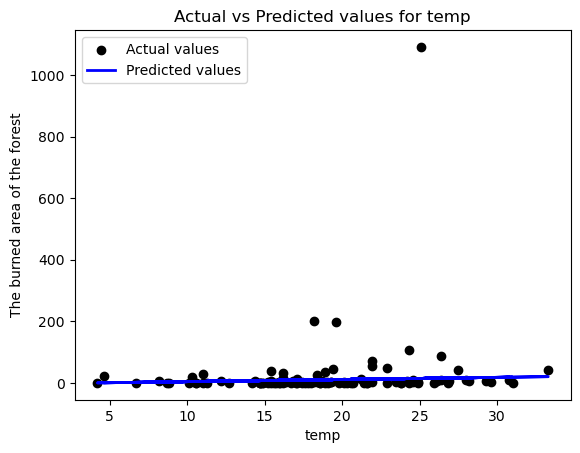

In [77]:
# Finding the best variable based on R-squared value
best_var_r2 = max(results, key=lambda x: results[x]['R2'])
print(f"The best variable for prediction based on R-squared is {best_var_r2} with an R-squared value of {results[best_var_r2]['R2']}. \n")

# Plotting the actual vs predicted values for the best variable based on R-squared
X = df[[best_var_r2]]
y = df['area']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

plt.scatter(X_test, y_test, color='black', label='Actual values')
plt.plot(X_test, y_pred, color='blue', linewidth=2, label='Predicted values')
plt.title(f'Actual vs Predicted values for {best_var_r2}')
plt.xlabel(best_var_r2)
plt.ylabel('The burned area of the forest')
plt.legend()
plt.show()


Comment: According to the performance testing results, "temp " can be assumed as the best independent variable for the prediction among these three independent variables: temp, RH, and rain.

### Exercise 18: Now we will use multiple features to predict the grade and compare the result to the single viable. To do so we need to redefine the X variable as follows. (Note: we cannot plot multidimensional plots, thus you should not plot the data as in exercise 16)

Mean Absolute Error: 25.758747927985585
Mean Squared Error: 12086.041002956192
R-squared: 9.954258760325185e-05


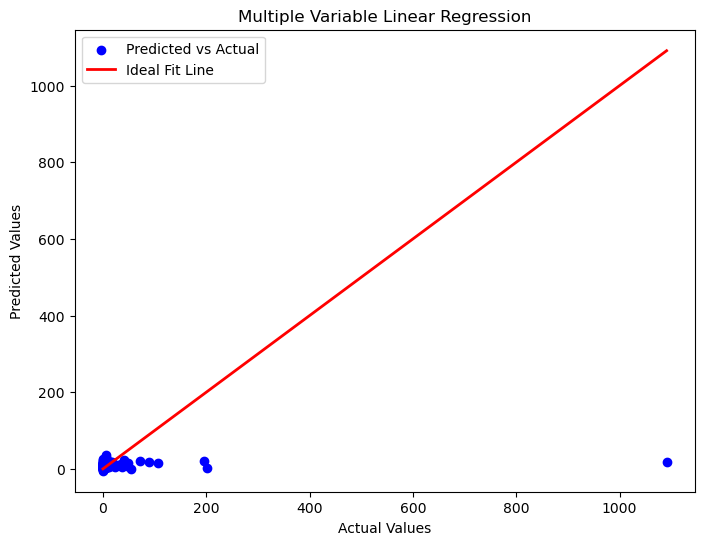

In [78]:
# Selecting the feature and target variables
X = df[['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']]
y = df['area']  # Target variable

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Creating and fitting the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predicting the target values
y_pred = model.predict(X_test)

# Calculating Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

# Calculating Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

# Calculating R-squared
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

# Visualization: Actual vs Predicted Values with Line Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2, label='Ideal Fit Line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Multiple Variable Linear Regression')
plt.legend()
plt.show()

#### Compare the result to the single viable

Mean Absolute Error: 26.056523592478257
Mean Squared Error: 12240.693163420925
R-squared: -0.01269511580803484


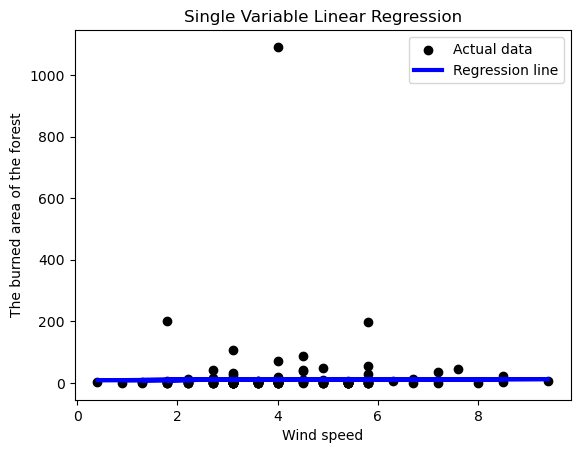

In [80]:
# Selecting the feature and target variables 
X = df[['wind']] # Feature variable 
y = df['area'] # Target variable

# Splitting the data into training and testing sets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Creating and fitting the model 
model = LinearRegression() 
model.fit(X_train, y_train)

# Predicting the target values 
y_pred = model.predict(X_test)

# Calculating Mean Absolute Error 
mae = mean_absolute_error(y_test, y_pred) 
print("Mean Absolute Error:", mae) 

# Calculating Mean Squared Error 
mse = mean_squared_error(y_test, y_pred) 
print("Mean Squared Error:", mse) 

# Calculating R-squared 
r2 = r2_score(y_test, y_pred) 
print("R-squared:", r2)

# Plotting the data points and the regression line 
plt.scatter(X_test, y_test, color='black', label='Actual data') 
plt.plot(X_test, y_pred, color='blue', linewidth=3, label='Regression line') 
plt.title('Single Variable Linear Regression') 
plt.xlabel('Wind speed') 
plt.ylabel('The burned area of the forest') 
plt.legend() 
plt.show()

By comparing the performance of a single-variable model (using just one feature) to a model with multiple features, we can see if using additional data points (features) improves the accuracy of predicting the burned area of the forest.

#### Look back at the corelation matrix and find the most useful features you may use to get best results. 

While the correlations are generally weak, temp, DMC, and DC appear to be the most influential predictors of area based on their correlations. These features should be prioritized in predictive modeling or analysis tasks related to predicting the area. However, the weak correlations suggest that other factors not included in this dataset might also play a significant role in determining the area.

## References

Cortez, P., and Morais, A., 2008. 'Forest Fires. UCI Machine Learning Repository', https://doi.org/10.24432/C5D88D.
